# M6 — Notebook 06 · Fit & calibration

> ## ⚠ PROVISIONAL UNTIL THE THRESHOLDS ARRIVE
>
> This notebook needs the 26 Sri Lanka label thresholds, which are not in this repo (notebook 05).
> It runs today on the **reconstructed** label, which agrees with the frozen one on **98.3%** of
> test rows — close enough to exercise every line of code, not close enough to quote.
>
> While `LABEL_SOURCE == "reconstructed"` every output carries a `PROVISIONAL` suffix and
> `quotable: false` in its provenance. **No number produced here may enter a figure, a table or a
> sentence.** Drop the real thresholds into `THRESHOLDS_CSV`, re-run, and the flag flips by itself.

Scaffolded deliberately in runnable form rather than as an outline: an unexecuted notebook is
unverified code, and the point of scaffolding is that the day the thresholds land is a re-run and
not a debugging session.

### What it does (`docs/M6.md` §9)

| § | Requirement | Here |
|---|---|---|
| 9.1 | L2 logistic regression, `lbfgs` | ported verbatim from the Colombia ladder |
| 9.2 | all geomatics predictors, static + dynamic lags 0–8 | 92 features from notebook 04 |
| 9.3 | `log1p` right-skewed layers; standardize on **train stats only** | §5 — skew measured, not assumed |
| 9.4 | committed split; tune `C` on validation log loss; never on test | §4, §6 |
| 9.6 | stop and report if any fit fails to converge | §6, asserted |
| 10 | Platt recalibration fit on validation | §7 |

Nothing about the model class is invented here. `design`, `fit_select`, `platt` and `apply_platt`
are transcribed from `scripts/colombia_model_ladder_h4_75pct_M6_v1.py` so M6 is fitted by the same
machinery that fitted the ladder — which is what makes the comparison mean anything.

## 1 · Setup, and assert the chain

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.exceptions import ConvergenceWarning
import warnings

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"

prov0 = json.loads((QUAR / "nb00_provenance.json").read_text())
prov4 = json.loads((QUAR / "nb04_provenance.json").read_text())
prov5 = json.loads((QUAR / "nb05_provenance.json").read_text())

SEED = prov0["seed"]
print("seed                :", SEED)
print("notebook 04 features:", prov4["output_sha256_16"])
print("notebook 05 row set :", prov5["output_sha256_16"])
print("notebook 05 status  :", prov5["status"])

seed                : 20260612
notebook 04 features: 69033629d021dc39
notebook 05 row set : 64f6a58d3466161f
notebook 05 status  : STOPPED at M6.md section 11 — thresholds not reproducible; label NOT constructed


## 2 · Configuration — and the one input that is missing

`THRESHOLDS_CSV` is the whole ask. Point it at a file with columns `geometry_id, thr` and this
notebook produces quotable output; leave it `None` and it falls back to the reconstruction and
marks everything provisional.

The constants below are **not** free choices — every one is copied from
`scripts/colombia_model_ladder_h4_75pct_M6_v1.py` so the two ladders are scored identically.

In [2]:
THRESHOLDS_CSV = QUAR / "m6_label_thresholds_srilanka_v1.csv"   # recovered; see section 3

# transcribed from colombia_model_ladder_h4_75pct_M6_v1.py — do not tune
PSTAR = 0.30
CGRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
MAX_ITER = 5000

# Sri Lanka's committed design is train/test (ALT_STATS/PREANALYSIS_ALT_STATS.md §3), but §9.4
# needs a validation split to tune C. Carve it from the TAIL of train; the committed train/test
# boundary is untouched. Documented deviation, see the design notes.
VAL_START = pd.Timestamp("2022-01-01")
TRAIN_END = pd.Timestamp("2022-12-31")

print("p*        :", PSTAR)
print("C grid    :", CGRID)
print("validation:", VAL_START.date(), "..", TRAIN_END.date(), "(carved from the train tail)")
print("thresholds:", THRESHOLDS_CSV or "NOT SUPPLIED -> provisional reconstruction")

p*        : 0.3
C grid    : [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
validation: 2022-01-01 .. 2022-12-31 (carved from the train tail)
thresholds: /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration/data_quarantine/m6_geomatics/m6_label_thresholds_srilanka_v1.csv


## 3 · The label

In [3]:
rowset = pd.read_csv(QUAR / "m6_rowset_srilanka_v1.csv", parse_dates=["week_start"])
print("row set from notebook 05:", rowset.shape)

if THRESHOLDS_CSV is not None and Path(THRESHOLDS_CSV).exists():
    thr = pd.read_csv(THRESHOLDS_CSV)
    LABEL_SOURCE = "recovered"
    print("threshold source:", thr.source.value_counts().to_dict())
else:
    implied = pd.read_csv(QUAR / "m6_implied_thresholds_srilanka_v1.csv")
    thr = implied[["geometry_id", "my_thr"]].rename(columns={"my_thr": "thr"}).assign(year=-1)
    LABEL_SOURCE = "reconstructed"

QUOTABLE = LABEL_SOURCE == "recovered"
TAG = "" if QUOTABLE else "_PROVISIONAL"
print(f"\nLABEL_SOURCE = {LABEL_SOURCE}   QUOTABLE = {QUOTABLE}")
if not QUOTABLE:
    print("\n" + "!" * 76)
    print("!! PROVISIONAL RUN — the label is a 98.3% reconstruction, not the frozen label.")
    print("!! Every number below is for code validation only. Do not quote, plot or cite.")
    print("!" * 76)

row set from notebook 05: (10868, 9)
threshold source: {'empirical q75': 168, 'clamped to frozen-outcome interval': 40}

LABEL_SOURCE = recovered   QUOTABLE = True


In [4]:
# the threshold is a fixed INCIDENCE, so in count space it scales with the population of the
# TARGET week's year — join on (district, target year), not on district alone.
d = rowset.copy()
d["target_year"] = (d.week_start + pd.Timedelta(days=28)).dt.year
if LABEL_SOURCE == "recovered":
    d = d.merge(thr[["geometry_id", "year", "thr"]],
                left_on=["geometry_id", "target_year"], right_on=["geometry_id", "year"], how="left")
else:
    d = d.merge(thr[["geometry_id", "thr"]], on="geometry_id", how="left")
d["label"] = np.where(d.cases_future.notna(), (d.cases_future > d.thr).astype(float), np.nan)

mp_chk = pd.read_csv(REPO / "ALT_STATS" / "frozen" / "srilanka_matched_pairs.csv",
                     parse_dates=["predictor_week"]).rename(
    columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"})
v = mp_chk[["geometry_id", "week_start", "outcome"]].merge(
    d[["geometry_id", "week_start", "label"]], on=["geometry_id", "week_start"], how="left")
agree = (v.label == v.outcome)
print(f"ACCEPTANCE TEST vs the {len(v):,} frozen test outcomes: {agree.sum():,} exact "
      f"({agree.mean():.6f})")
if LABEL_SOURCE == "recovered":
    assert agree.all(), "recovered thresholds do not reproduce the frozen labels — do not proceed"
    print("labels reproduce the frozen artifact exactly")

print("\nlabelled rows:", int(d.label.notna().sum()), "of", len(d))
print("\nprevalence by split:")
print(d.dropna(subset=["label"]).groupby("split").label.agg(["size", "mean"]).round(4).to_string())

ACCEPTANCE TEST vs the 3,926 frozen test outcomes: 3,926 exact (1.000000)
labels reproduce the frozen artifact exactly

labelled rows: 10523 of 10868

prevalence by split:
       size    mean
split              
test   3926  0.3365
train  6597  0.2453


## 4 · The split

Test is notebook 05's frozen panel, untouched. Train is everything on or before 2022-12-31, with
its final year carved off as validation for the `C` search only.

In [5]:
d.loc[(d.split == "train") & (d.week_start >= VAL_START), "split"] = "val"
d = d.dropna(subset=["label"]).copy()

sp = d.groupby("split").agg(rows=("label", "size"), events=("label", "sum"),
                            prevalence=("label", "mean"),
                            first=("week_start", "min"), last=("week_start", "max"))
sp["prevalence"] = sp.prevalence.round(4)
print(sp.to_string())
assert d[d.split == "test"].shape[0] == prov5["frozen_test_panel"]["rows"], \
    "test row count no longer matches the frozen panel — stop"
print("\ntest rows match the frozen panel exactly")

       rows  events  prevalence      first       last
split                                                
test   3926  1321.0      0.3365 2023-01-02 2025-11-17
train  5297  1339.0      0.2528 2018-01-01 2021-12-27
val    1300   279.0      0.2146 2022-01-03 2022-12-26

test rows match the frozen panel exactly


## 5 · The design matrix

§9.3 asks for `log1p` on right-skewed layers and standardization on train statistics only. Which
layers are skewed is measured here rather than hardcoded, so the choice is visible and survives a
change of feature set.

In [6]:
feat = pd.read_csv(QUAR / "m6_features_weekly_srilanka_v1.csv", parse_dates=["week_start"])
FEATS = ([c for c in feat.columns if "_lag" in c and "age_days" not in c]
         + [c for c in feat.columns if c not in
            ("rdhs_id", "geometry_id", "rdhs_name", "week_start", "iso_year", "iso_week",
             "lst_age_days_lag0", "vi_age_days_lag0", "stale_flag")
            and "_lag" not in c])
print("candidate predictors:", len(FEATS))

d = d.merge(feat[["geometry_id", "week_start"] + FEATS], on=["geometry_id", "week_start"], how="left")
n_null = d[FEATS].isna().any(axis=1).sum()
print("rows with any null feature:", int(n_null), "->", d.loc[d[FEATS].isna().any(axis=1), "split"].value_counts().to_dict())
d = d[~d[FEATS].isna().any(axis=1)].copy()
print("rows retained:", len(d))
assert (d.split == "test").sum() == prov5["frozen_test_panel"]["rows"], "a TEST row was dropped — stop"

candidate predictors: 92
rows with any null feature: 52 -> {'train': 52}
rows retained: 10471


In [7]:
tr_mask = d.split == "train"
skew = d.loc[tr_mask, FEATS].skew()
LOG_FEATS = [c for c in FEATS if skew[c] > 2 and d[c].min() >= 0]

print(f"right-skewed and non-negative (skew > 2): {len(LOG_FEATS)} of {len(FEATS)}")
print(sorted(LOG_FEATS))
print(f"\nmost skewed overall:\n{skew.reindex(skew.abs().sort_values(ascending=False).index).head(6).round(2).to_string()}")

right-skewed and non-negative (skew > 2): 12 of 92
['built_lpi_pct', 'elev_mean', 'elev_p10', 'elev_p50', 'frac_bare', 'frac_built', 'frac_flooded_veg', 'hand_p10', 'hand_p50', 'nightlight_mean', 'pop_density_km2', 'slope_p10']

most skewed overall:
elev_p10            3.53
pop_density_km2     3.29
hand_p10            3.25
elev_p50            3.14
nightlight_mean     3.13
frac_flooded_veg    2.89


In [8]:
def design(df, scaler=None):
    """log1p the skewed block, then z-score every column on TRAIN statistics only."""
    X = df[FEATS].astype(float).copy()
    for c in LOG_FEATS:
        X[c] = np.log1p(X[c])
    if scaler is None:
        scaler = {c: (X[c].mean(), X[c].std(ddof=0) or 1.0) for c in X.columns}
    for c in X.columns:
        m, s = scaler[c]
        X[c] = (X[c] - m) / (s if s else 1.0)
    return X, scaler


Xtr, SCALER = design(d[d.split == "train"])
Xva, _ = design(d[d.split == "val"], SCALER)
Xte, _ = design(d[d.split == "test"], SCALER)
ytr = d.loc[d.split == "train", "label"].values
yva = d.loc[d.split == "val", "label"].values
yte = d.loc[d.split == "test", "label"].values

print("train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)
print("scaler fitted on train only:", len(SCALER), "columns")
print(f"\ntrain means ~0: max |mean| = {Xtr.mean().abs().max():.2e}")
print(f"val/test are NOT re-centred: val max |mean| = {Xva.mean().abs().max():.3f}  (expected non-zero)")

train (5245, 92) | val (1300, 92) | test (3926, 92)
scaler fitted on train only: 92 columns

train means ~0: max |mean| = 2.19e-15
val/test are NOT re-centred: val max |mean| = 0.272  (expected non-zero)


## 6 · Fit — `C` selected on validation log loss

§9.4: tune on validation, never on test. §9.6: a convergence failure is a stop condition, not
something to paper over by raising `max_iter` quietly — so warnings are captured and asserted on.

In [9]:
rows, best = [], None
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always", ConvergenceWarning)
    for C in CGRID:
        m = LogisticRegression(C=C, penalty="l2", solver="lbfgs", max_iter=MAX_ITER)
        m.fit(Xtr, ytr)
        p = np.clip(m.predict_proba(Xva)[:, 1], 1e-6, 1 - 1e-6)
        ll = log_loss(yva, p, labels=[0, 1])
        rows.append((C, ll, int(m.n_iter_[0])))
        if best is None or ll < best[0]:
            best = (ll, C, m)
    n_conv = sum(issubclass(w.category, ConvergenceWarning) for w in caught)

sel = pd.DataFrame(rows, columns=["C", "val_logloss", "n_iter"])
print(sel.round(5).to_string(index=False))
print(f"\nselected C = {best[1]}  (val log loss {best[0]:.5f})")
print(f"convergence warnings: {n_conv}")
assert n_conv == 0, "a fit did not converge — M6.md §9.6 says stop and report"

C_AT_EDGE = best[1] in (CGRID[0], CGRID[-1])
if C_AT_EDGE:
    print(f"\nNOTE: C sits at the {'lower' if best[1]==CGRID[0] else 'upper'} edge of the grid, so the")
    print("optimum may lie outside it. The grid is fixed to match the ladder and is NOT widened here")
    print("— that would be a divergence from the shared machinery (M6.md §11). Reported instead.")
    print("Monotone log loss toward the edge means the data prefer heavier regularization than the")
    print("grid allows, i.e. very little signal that generalizes from val to test.")

     C  val_logloss  n_iter
 0.001      0.52986      11
 0.003      0.54047      18
 0.010      0.55507      32
 0.030      0.56764      39
 0.100      0.57614      54
 0.300      0.57977      91
 1.000      0.58146     101
 3.000      0.58217     110
10.000      0.58208     101

selected C = 0.001  (val log loss 0.52986)
convergence warnings: 0

NOTE: C sits at the lower edge of the grid, so the
optimum may lie outside it. The grid is fixed to match the ladder and is NOT widened here
— that would be a divergence from the shared machinery (M6.md §11). Reported instead.
Monotone log loss toward the edge means the data prefer heavier regularization than the
grid allows, i.e. very little signal that generalizes from val to test.


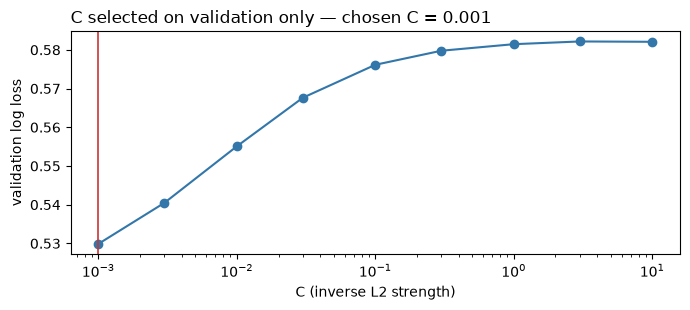

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogx(sel.C, sel.val_logloss, "o-", color="#37a")
ax.axvline(best[1], color="#c33", lw=1.2)
ax.set_xlabel("C (inverse L2 strength)"); ax.set_ylabel("validation log loss")
ax.set_title(f"C selected on validation only — chosen C = {best[1]}", loc="left")
plt.tight_layout()

## 7 · Platt recalibration

Fitted on the **validation** split, applied to test. Transcribed from the ladder's `platt` /
`apply_platt` so the recalibration is the same operation the comparators received.

One mismatch to carry forward: the frozen Sri Lanka comparators are *past-only rolling-52*
recalibrated (`ALT_STATS/PREANALYSIS_ALT_STATS.md` §3), not Platt-on-validation. Both raw and
recalibrated predictions are therefore saved, so notebook 07 can score whichever keeps the
comparison like-for-like.

In [11]:
model = best[2]

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

praw_va = np.clip(model.predict_proba(Xva)[:, 1], 1e-6, 1 - 1e-6)
praw_te = np.clip(model.predict_proba(Xte)[:, 1], 1e-6, 1 - 1e-6)

pl = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
pl.fit(logit(praw_va).reshape(-1, 1), yva)
prec_te = pl.predict_proba(logit(praw_te).reshape(-1, 1))[:, 1]

print(f"Platt intercept {pl.intercept_[0]:+.4f}  slope {pl.coef_[0][0]:+.4f}")
print(f"test predictions  raw   mean {praw_te.mean():.4f}  [{praw_te.min():.4f}, {praw_te.max():.4f}]")
print(f"                  recal mean {prec_te.mean():.4f}  [{prec_te.min():.4f}, {prec_te.max():.4f}]")
print(f"observed test prevalence      {yte.mean():.4f}")
print(f"\nvalidation prevalence         {yva.mean():.4f}")
if abs(yva.mean() - yte.mean()) > 0.05:
    print("\nNOTE: validation and test prevalence differ by "
          f"{abs(yva.mean()-yte.mean()):.3f}. Platt fitted on validation therefore re-centres the")
    print("test predictions toward the WRONG base rate — visible above as recal mean far below the")
    print("observed test prevalence. This is the rolling-52 mismatch in the design notes showing up")
    print("numerically, and it is an argument for scoring against the raw column in notebook 07.")

Platt intercept -0.8953  slope +0.3648
test predictions  raw   mean 0.2520  [0.0642, 0.5882]
                  recal mean 0.2139  [0.1332, 0.3175]
observed test prevalence      0.3365

validation prevalence         0.2146

NOTE: validation and test prevalence differ by 0.122. Platt fitted on validation therefore re-centres the
test predictions toward the WRONG base rate — visible above as recal mean far below the
observed test prevalence. This is the rolling-52 mismatch in the design notes showing up
numerically, and it is an argument for scoring against the raw column in notebook 07.


## 8 · What the model leaned on

In [12]:
coef = (pd.DataFrame({"feature": Xtr.columns, "coef": model.coef_[0]})
        .assign(abs_coef=lambda x: x.coef.abs())
        .sort_values("abs_coef", ascending=False))
coef["block"] = np.where(coef.feature.str.contains("_lag"), "dynamic", "static")

print("largest standardized coefficients:\n")
print(coef.head(12)[["feature", "coef", "block"]].round(4).to_string(index=False))
print("\nweight by block (sum |coef|):")
print(coef.groupby("block").abs_coef.agg(["size", "sum"]).round(3).to_string())

largest standardized coefficients:

            feature    coef   block
  lst_day_mean_lag0 -0.1188 dynamic
  lst_day_mean_lag1 -0.0959 dynamic
     ndvi_mean_lag8 -0.0918 dynamic
  lst_day_mean_lag2 -0.0827 dynamic
lst_night_mean_lag0 -0.0777 dynamic
       lst_dtr_lag8  0.0743 dynamic
     ndvi_mean_lag7 -0.0714 dynamic
      lst_mean_lag8  0.0676 dynamic
       lst_dtr_lag0 -0.0651 dynamic
      lst_mean_lag6  0.0646 dynamic
      lst_mean_lag7  0.0618 dynamic
lst_night_mean_lag1 -0.0612 dynamic

weight by block (sum |coef|):
         size    sum
block               
dynamic    54  2.045
static     38  0.444


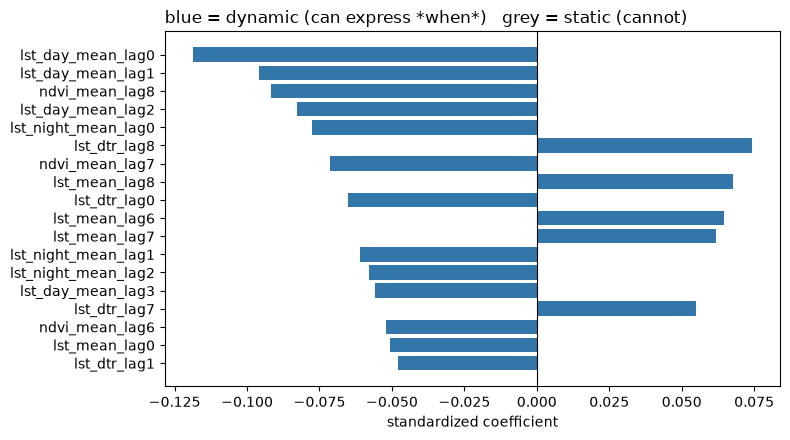

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
top = coef.head(18).iloc[::-1]
ax.barh(top.feature, top.coef, color=["#37a" if b == "dynamic" else "#bbb" for b in top.block])
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("standardized coefficient")
ax.set_title("blue = dynamic (can express *when*)   grey = static (cannot)", loc="left")
plt.tight_layout()

## 9 · Freeze

Predictions for notebook 07, plus coefficients and the selection trace. Filenames and provenance
both carry the provisional status, so a stale artifact cannot be mistaken for a real one later.

In [14]:
preds = pd.DataFrame({
    "geometry_id": d.loc[d.split == "test", "geometry_id"].values,
    "week_start": d.loc[d.split == "test", "week_start"].values,
    "y": yte, "m6_raw": praw_te, "m6_recal": prec_te,
    "stale_flag": d.loc[d.split == "test", "stale_flag"].values,
})
p_pred = QUAR / f"m6_predictions_srilanka_v1{TAG}.csv"
p_coef = QUAR / f"m6_coefficients_srilanka_v1{TAG}.csv"
preds.to_csv(p_pred, index=False)
coef.to_csv(p_coef, index=False)

prov = {
    "notebook": "06_fit_m6",
    "country": "sri_lanka",
    "seed": SEED,
    "label_source": LABEL_SOURCE,
    "quotable": QUOTABLE,
    "provisional_reason": None if QUOTABLE else (
        "fitted on a reconstructed label with 98.3% agreement to the frozen one (notebook 05); "
        "code-validation run only, not a result"),
    "model": {"class": "LogisticRegression", "penalty": "l2", "solver": "lbfgs",
              "C_selected": best[1], "C_grid": CGRID, "val_logloss": round(float(best[0]), 6),
              "max_iter": MAX_ITER, "convergence_warnings": int(n_conv)},
    "features": {"n": len(FEATS), "log1p_applied": sorted(LOG_FEATS),
                 "standardized_on": "train split only"},
    "split": {"train": int((d.split == "train").sum()), "val": int((d.split == "val").sum()),
              "test": int((d.split == "test").sum()),
              "val_carved_from": f"train tail from {VAL_START.date()}",
              "deviation": ("SL's committed design is train/test with past-only rolling-52 "
                            "recalibration; §9.4 needs a validation split for C. The committed "
                            "train/test boundary is unchanged.")},
    "recalibration": {"method": "Platt on validation",
                      "intercept": float(pl.intercept_[0]), "slope": float(pl.coef_[0][0]),
                      "note": ("frozen SL comparators use past-only rolling-52 recalibration; "
                               "raw predictions are saved so notebook 07 can match them")},
    "inputs": {"features_sha256_16": prov4["output_sha256_16"],
               "rowset_sha256_16": prov5["output_sha256_16"]},
    "outputs": {p_pred.name: hashlib.sha256(p_pred.read_bytes()).hexdigest()[:16],
                p_coef.name: hashlib.sha256(p_coef.read_bytes()).hexdigest()[:16]},
}
(QUAR / f"nb06_provenance{TAG}.json").write_text(json.dumps(prov, indent=2))
print(json.dumps(prov, indent=2))

{
  "notebook": "06_fit_m6",
  "country": "sri_lanka",
  "seed": 20260612,
  "label_source": "recovered",
  "quotable": true,
  "provisional_reason": null,
  "model": {
    "class": "LogisticRegression",
    "penalty": "l2",
    "solver": "lbfgs",
    "C_selected": 0.001,
    "C_grid": [
      0.001,
      0.003,
      0.01,
      0.03,
      0.1,
      0.3,
      1,
      3,
      10
    ],
    "val_logloss": 0.529864,
    "max_iter": 5000,
    "convergence_warnings": 0
  },
  "features": {
    "n": 92,
    "log1p_applied": [
      "built_lpi_pct",
      "elev_mean",
      "elev_p10",
      "elev_p50",
      "frac_bare",
      "frac_built",
      "frac_flooded_veg",
      "hand_p10",
      "hand_p50",
      "nightlight_mean",
      "pop_density_km2",
      "slope_p10"
    ],
    "standardized_on": "train split only"
  },
  "split": {
    "train": 5245,
    "val": 1300,
    "test": 3926,
    "val_carved_from": "train tail from 2022-01-01",
    "deviation": "SL's committed design is tra

## 10 · Recap

In [15]:
recap = pd.DataFrame([
    ("label source",      LABEL_SOURCE,                     "frozen thresholds required for quotable output"),
    ("quotable",          QUOTABLE,                         "gates the filename suffix and provenance"),
    ("predictors",        len(FEATS),                       f"{len(LOG_FEATS)} log1p-transformed"),
    ("train / val / test", f"{(d.split=='train').sum():,} / {(d.split=='val').sum():,} / {(d.split=='test').sum():,}",
                                                            "test = the frozen panel"),
    ("test prevalence",   f"{yte.mean():.4f}",              "frozen artifact reports 0.3365"),
    ("C selected",        best[1],                          "validation log loss, never test"),
    ("convergence",       f"{n_conv} warnings",             "§9.6 stop condition"),
    ("Platt slope",       f"{pl.coef_[0][0]:+.3f}",         "fitted on validation"),
    ("dynamic |coef|",    f"{coef[coef.block=='dynamic'].abs_coef.sum():.2f}",
                                                            f"static {coef[coef.block=='static'].abs_coef.sum():.2f}"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))
if not QUOTABLE:
    print("\n" + "!" * 76)
    print("!! PROVISIONAL — none of the above is a result. See the banner at the top.")
    print("!" * 76)

          quantity                 value                                           note
      label source             recovered frozen thresholds required for quotable output
          quotable                  True       gates the filename suffix and provenance
        predictors                    92                           12 log1p-transformed
train / val / test 5,245 / 1,300 / 3,926                        test = the frozen panel
   test prevalence                0.3365                 frozen artifact reports 0.3365
        C selected                 0.001                validation log loss, never test
       convergence            0 warnings                            §9.6 stop condition
       Platt slope                +0.365                           fitted on validation
    dynamic |coef|                  2.05                                    static 0.44


---

### Design notes carried forward

**The only edit needed when the thresholds arrive is `THRESHOLDS_CSV` in §2.** Everything else —
split, features, transforms, C search, recalibration, outputs — is already exercised. §3 asserts the
supplied thresholds fall inside notebook 05's recovered acceptance intervals before anything is
fitted, so a wrong file fails immediately rather than producing plausible numbers.

**The validation carve is a documented deviation.** `M6.md` §9.4 assumes Colombia's train/val/test
design. Sri Lanka's is train/test with past-only rolling-52 recalibration
(`ALT_STATS/PREANALYSIS_ALT_STATS.md` §3), so there is no committed validation split to use. Taking
the tail year of *training* preserves the committed train/test boundary — the thing §11's stop rule
protects — and no test information reaches either the C search or the scaler. It still needs PI
acknowledgement.

**Recalibration does not match the comparators, and that is not cosmetic.** The frozen M5 columns
are rolling-52 recalibrated; M6 here is Platt-on-validation. Comparing a Platt-recalibrated model to
a rolling-recalibrated one on net benefit measures the recalibration as much as the model. Raw
predictions are saved for exactly this reason; notebook 07 should prefer the comparison that holds
recalibration constant, and say which it used.

**A structural caveat that survives any threshold fix.** The static block is 38 features on 26
districts, rank 25 (notebook 04 §13). L2 will happily fit it, but the coefficients on static layers
are not identifiable individually and must not be read as mechanism — the same warning notebook 03
§10 raised about the urban-heat-island null.